## Introduction to Quantum Computing: Labs

### Solution for Lab 5: Grover's Algorithm

### Grover's Algorithm

**Grover's Algorithm** is a central quantum algorithm for solving *unstructured search* problems.
It allows finding a searched element in a set of $N$ possibilities in only $O(\sqrt{N})$ steps, making it quadratically faster than any classical search algorithm.

The idea: Instead of checking each element individually, all possibilities are considered simultaneously in a **superposition**.
Through the targeted interplay of an **Oracle** and **Amplitude Amplification**, the correct solutions are gradually "filtered out".

**Three Components:**

1. **Superposition:** Generation of an equally distributed superposition of all possible states.
2. **Oracle:** Marking of the solution states by flipping the sign of their amplitude.
3. **Amplitude Amplification:** Amplification of the marked states through interference, so that their measurement probability increases.

After a certain number of iterations, the probability of obtaining the sought solution upon measurement is very high.

In this lab, we will implement all steps of Grover's algorithm ourselves. To do this, we will write a Python routine for each of the three components:

- `initial_state(num_data_qubits, num_ancilla_qubits)`
- `oracle(num_data_qubits)`
- `amplitude_amplification(num_data_qubits, num_ancilla_qubits)`

The following input parameters apply:

- `num_data_qubits`: Number of data qubits, i.e., the qubits carrying the solution information.
- `num_ancilla_qubits`: Number of ancilla qubits, i.e., the qubits needed for the oracle implementation.

The oracle takes only `num_data_qubits` as input, as the number of ancilla qubits depends on the specific implementation of the oracle.

In [1]:
# Imports
import numpy as np
from qiskit import QuantumCircuit

# Helper function for outputting the statevector
from qc_lecture_tools.grover import print_grover_states

### Exercise 1: Implementation of Equal Superposition for $n$ Qubits

In the first step of Grover's algorithm, we want to create an initial state in which **all possible bitstrings of the data qubits are equally likely**.
To do this, we bring the data qubits into an equal superposition, while all auxiliary qubits (ancilla) remain in the $\ket{0}$ state.

Implement a Python function that prepares the state for an arbitrary number of data and ancilla qubits.


In [2]:
def initial_state(num_data_qubits: int, num_ancilla_qubits: int) -> QuantumCircuit:
    """
    Creates the initial equal superposition state of the Grover algorithm

    Args:
        num_data_qubits (int): Number of the data qubits
        num_ancilla_qubits (int): Number of ancilla qubits

    Returns:
        Quantum circuit containing the quantum gates to create the equal superposition state 
    """

    # Hadamard gates on each data qubit
    qc_initial_state = QuantumCircuit(num_data_qubits + num_ancilla_qubits)
    list_of_qubits = list(range(num_data_qubits))
    qc_initial_state.h(list_of_qubits)

    return qc_initial_state

Test your implementation with the following code:

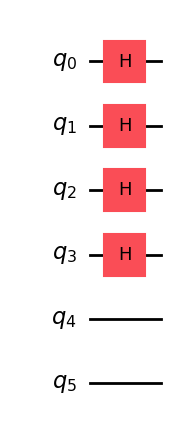

In [3]:
num_data_qubits = 4
num_ancilla_qubits = 2
qc_initial_state = initial_state(num_data_qubits, num_ancilla_qubits)
qc_initial_state.draw("mpl")

### Exercise 2: Simple Oracle for $n$ Qubits

In the next step, we implement a simple example of a **Grover Oracle**.
Our oracle should "trigger" exactly when all data qubits are in the state $\ket{1}$.
This means: For this basis state, the oracle should **invert the sign of the amplitude**, while all other states remain **unchanged**.
The implementation should support an **arbitrary number of qubits**!

#### Exercise 2.1: Implementation with a Multi-Controlled Z-Gate

Such an oracle can be realized using a **multi-controlled Z-gate**:
The Z-gate is only applied if *all* control qubits have the value 1.
In this implementation, no additional ancilla qubits are necessary.

**Hint:**
There is no direct multi-controlled Z-gate in Qiskit.
However, we can use the identity $Z = H X H$ to implement the desired behavior with a **multi-controlled X-gate** (`mcx`).
To do this, a Hadamard gate is applied to the target qubit before and after the `mcx` gate.

The multi-controlled X-gate can be used as follows:

```python
quantum_circuit.mcx(list_control_qubits, target_qubit)
```

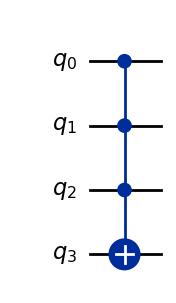

In [4]:
quantum_circuit = QuantumCircuit(4)
quantum_circuit.mcx([0, 1, 2], 3)
quantum_circuit.draw("mpl")

In [5]:
def oracle(num_data_qubits: int) -> QuantumCircuit:
    """ Implementation of the oracle function for the Grover algorithm that finds the |1...11> state
     
    Args:
        num_data_qubits (int): Number of data qubits  
        
    Returns:
        Quantum circuit of the oracle
    """

    # Implementation of the oracle with the controlled-Z gate implemented by HZH
    qc_oracle = QuantumCircuit(num_data_qubits)
    list_of_qubits = list(range(num_data_qubits))
    qc_oracle.h(num_data_qubits - 1)
    qc_oracle.mcx(list_of_qubits[:-1], num_data_qubits - 1)
    qc_oracle.h(num_data_qubits - 1)
    return qc_oracle

Test your implementation with the following code:

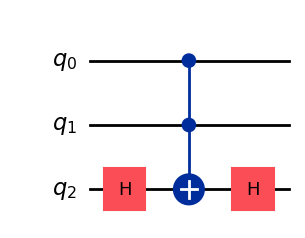

In [6]:
num_data_qubits = 3
qc_oracle = oracle(num_data_qubits)
qc_oracle.draw("mpl")

### Exercise 2.2: Applying the Oracle to the Equal Superposition State

Verify whether the oracle implemented in **Exercise 2.1** shows the expected behavior on the **equal superposition initial state** from **Exercise 1**.
Use **three data qubits** for this.

Proceed as follows:

1. Create an **empty quantum circuit** with the total number of required qubits.
2. Generate the **initial state** with your function `initial_state(...)` and append it to the empty circuit using the `compose` function.
3. Then create the **oracle** and append it as well using `compose`.
4. Analyze the resulting quantum state with the helper function:
   ```python
   print_grover_states(quantum_circuit, num_data_qubits)
   ```

**Hint:** With the following Qiskit function, a second circuit (``quantum_circuit2``) can be appended to an existing one (``quantum_circuit1``):

```python
quantum_circuit1.compose(quantum_circuit2, inplace=True)
```

In [7]:
num_data_qubits = 3
num_ancilla_qubits = 0
num_qubits = num_data_qubits + num_ancilla_qubits
qc_grover = QuantumCircuit(num_qubits)
qc_grover.compose(initial_state(num_data_qubits, num_ancilla_qubits), inplace=True)
qc_grover.compose(oracle(num_data_qubits), inplace=True)

print_grover_states(qc_grover, num_data_qubits)

Found basis states with non-zero amplitudes:
000:  0.35  Probability:  0.12
001:  0.35  Probability:  0.12
010:  0.35  Probability:  0.12
011:  0.35  Probability:  0.12
100:  0.35  Probability:  0.12
101:  0.35  Probability:  0.12
110:  0.35  Probability:  0.12
111: -0.35  Probability:  0.12


### Exercise 2.3: Implementation using the Compute–Uncompute Method

In this exercise, the oracle is to be implemented using the **Compute–Uncompute Method**.
Here, an additional **ancilla qubit** is used, which serves as the target for the calculation of the oracle function.

The basic idea of this method is to first calculate the desired logical expression (e.g., "all qubits = 1"), write the result to the **ancilla qubit**, then invert the sign of the target state using a Z-gate, and finally reverse the calculation step (*uncompute*).
This leaves the original quantum state of the data qubits unchanged, while the ancilla qubit realizes the sign change.
After the oracle calculation, the ancilla qubit must be back in the original state $\ket{0}$.

The query whether all data qubits have the value 1 can be implemented with the `mcx` gate.


In [8]:
def oracle_ancilla(num_data_qubits:int) -> QuantumCircuit:
    """ Implementation of the oracle function for the Grover algorithm that finds the |1...11> state
    and uses one ancilla qubit
     
    Args:
        num_data_qubits (int): Number of data qubits  
        
    Returns:
        Quantum circuit of the oracle with additional ancilla qubits
        
    """ 

    # Implementation with one additional ancilla qubit
    qc_oracle = QuantumCircuit(num_data_qubits + 1)
    list_of_qubits = list(range(num_data_qubits))
    qc_oracle.mcx(list_of_qubits, num_data_qubits)
    qc_oracle.z(num_data_qubits)
    qc_oracle.mcx(list_of_qubits, num_data_qubits)
    return qc_oracle

Test your implementation with the following code:

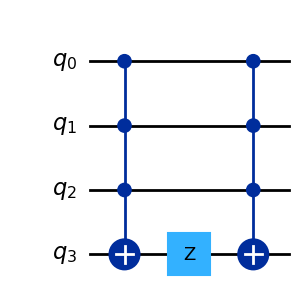

In [9]:
num_data_qubits = 3
num_ancilla_qubits = 1
qc_oracle = oracle_ancilla(num_data_qubits)
qc_oracle.draw("mpl")

### Exercise 2.4: Application of the Compute–Uncompute Oracle

Apply the oracle implemented in **Exercise 2.3** to the **equal superposition state** from **Exercise 1**.
Again, use **three data qubits**.

Proceed analogously to **Exercise 2.2**.
Note that an additional **ancilla qubit** is now used.

In [10]:
num_data_qubits = 3
num_ancilla_qubits = 1
num_qubits = num_data_qubits + num_ancilla_qubits
qc_grover = QuantumCircuit(num_qubits)
qc_grover.compose(initial_state(num_data_qubits, num_ancilla_qubits), inplace=True)
qc_grover.compose(oracle_ancilla(num_data_qubits), inplace=True)

print_grover_states(qc_grover, 3)

Found basis states with non-zero amplitudes:
000 0:  0.35  Probability:  0.12
001 0:  0.35  Probability:  0.12
010 0:  0.35  Probability:  0.12
011 0:  0.35  Probability:  0.12
100 0:  0.35  Probability:  0.12
101 0:  0.35  Probability:  0.12
110 0:  0.35  Probability:  0.12
111 0: -0.35  Probability:  0.12


### Exercise 3: Amplitude Amplification

In **Exercise 3**, we implement the third central component of Grover's algorithm: **Amplitude Amplification**.

The goal of this step is to further **amplify** the states marked by the oracle, while the amplitudes of the remaining states are attenuated.
To do this, we construct a quantum circuit that realizes a **reflection of the amplitudes about the mean state**, thus increasing the algorithm's chance of success.

You can find the corresponding circuit in the **lecture slides**.

**Exercise 3.1:**
Implement amplitude amplification for an arbitrary number of qubits.

In [11]:
def amplitude_amplification(num_data_qubits: int, num_ancilla_qubits: int) -> QuantumCircuit:
    """ Implementation of the amplitude amplification for the Grover algorithm
     
    Args:
        num_data_qubits (int): Number of data qubits on which the amplitude amplification is applied
        num_ancilla_qubits (int): Number of ancilla qubits that are untouched by the amplitude amplification
        
    Returns:
        Quantum circuit of the amplitude amplification
    """ 
    qc_amplification = QuantumCircuit(num_data_qubits + num_ancilla_qubits)
    list_of_qubits = list(range(num_data_qubits))
    qc_amplification.h(list_of_qubits)
    qc_amplification.x(list_of_qubits)
    qc_amplification.h(num_data_qubits - 1)
    qc_amplification.mcx(list_of_qubits[:-1], num_data_qubits - 1)
    qc_amplification.h(num_data_qubits - 1)
    qc_amplification.x(list_of_qubits)
    qc_amplification.h(list_of_qubits)

    qc_amplification.rz(2 * np.pi, 0)

    return qc_amplification

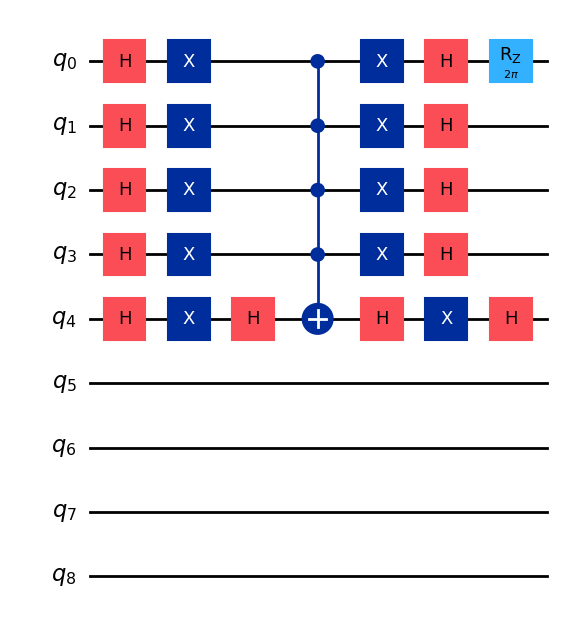

In [12]:
qc = amplitude_amplification(5, 4)

qc.draw('mpl')

**Exercise 3.2:**
What happens if we apply amplitude amplification to the initial equal superposition state?
Proceed as in **Exercise 2.2** and **Exercise 2.4**.

In [13]:
num_data_qubits = 4
num_ancilla_qubits = 1
num_qubits = num_data_qubits + num_ancilla_qubits
qc_grover = QuantumCircuit(num_qubits)
qc_grover.compose(initial_state(num_data_qubits, num_ancilla_qubits), inplace=True)
qc_grover.compose(amplitude_amplification(num_data_qubits, num_ancilla_qubits), inplace=True)

print_grover_states(qc_grover, 4)

Found basis states with non-zero amplitudes:
0000 0:  0.25  Probability:  0.06
0001 0:  0.25  Probability:  0.06
0010 0:  0.25  Probability:  0.06
0011 0:  0.25  Probability:  0.06
0100 0:  0.25  Probability:  0.06
0101 0:  0.25  Probability:  0.06
0110 0:  0.25  Probability:  0.06
0111 0:  0.25  Probability:  0.06
1000 0:  0.25  Probability:  0.06
1001 0:  0.25  Probability:  0.06
1010 0:  0.25  Probability:  0.06
1011 0:  0.25  Probability:  0.06
1100 0:  0.25  Probability:  0.06
1101 0:  0.25  Probability:  0.06
1110 0:  0.25  Probability:  0.06
1111 0:  0.25  Probability:  0.06


**Observation:** Applying amplitude amplification to the equal superposition state has no effect!

### Exercise 4: Assembling the Components into Grover's Algorithm

In the last step, we assemble the components from the previous tasks into the **Grover Algorithm** and analyze its functionality.

**Exercise 4.1:**
Construct the Grover algorithm with **one Grover step** for the oracle from **Exercise 2.3** using **four data qubits** and **one ancilla qubit**.
Use the `compose` function again for this.
Then analyze the resulting quantum state with the helper function `print_grover_states`.

What do you observe after applying one Grover step?

In [14]:
num_data_qubits = 4
num_ancilla_qubits = 1
num_qubits = num_data_qubits + num_ancilla_qubits
qc_grover = QuantumCircuit(num_qubits)

qc_grover.compose(initial_state(num_data_qubits, num_ancilla_qubits), inplace=True)
qc_grover.compose(oracle_ancilla(num_data_qubits), inplace=True)
qc_grover.compose(amplitude_amplification(num_data_qubits, num_ancilla_qubits), inplace=True)

print_grover_states(qc_grover, 4)

Found basis states with non-zero amplitudes:
0000 0:  0.19  Probability:  0.04
0001 0:  0.19  Probability:  0.04
0010 0:  0.19  Probability:  0.04
0011 0:  0.19  Probability:  0.04
0100 0:  0.19  Probability:  0.04
0101 0:  0.19  Probability:  0.04
0110 0:  0.19  Probability:  0.04
0111 0:  0.19  Probability:  0.04
1000 0:  0.19  Probability:  0.04
1001 0:  0.19  Probability:  0.04
1010 0:  0.19  Probability:  0.04
1011 0:  0.19  Probability:  0.04
1100 0:  0.19  Probability:  0.04
1101 0:  0.19  Probability:  0.04
1110 0:  0.19  Probability:  0.04
1111 0:  0.69  Probability:  0.47


**Observation:** The amplitude of the target state $\ket{1111}$ is increased, all others are decreased.

**Exercise 4.2:**
Now examine the result for **two**, **three**, and **four** repetitions of the Grover step.
What do you observe regarding the **amplitudes of the quantum states**?

In [15]:
num_data_qubits = 4
num_ancilla_qubits = 1
num_qubits = num_data_qubits + num_ancilla_qubits

qc_grover = QuantumCircuit(num_qubits)
qc_grover.compose(initial_state(num_data_qubits, num_ancilla_qubits), inplace=True)

for i in range(2):
    qc_grover.compose(oracle_ancilla(num_data_qubits), inplace=True)
    qc_grover.compose(amplitude_amplification(num_data_qubits, num_ancilla_qubits), inplace=True)

print_grover_states(qc_grover, 4)

Found basis states with non-zero amplitudes:
0000 0:  0.08  Probability:  0.01
0001 0:  0.08  Probability:  0.01
0010 0:  0.08  Probability:  0.01
0011 0:  0.08  Probability:  0.01
0100 0:  0.08  Probability:  0.01
0101 0:  0.08  Probability:  0.01
0110 0:  0.08  Probability:  0.01
0111 0:  0.08  Probability:  0.01
1000 0:  0.08  Probability:  0.01
1001 0:  0.08  Probability:  0.01
1010 0:  0.08  Probability:  0.01
1011 0:  0.08  Probability:  0.01
1100 0:  0.08  Probability:  0.01
1101 0:  0.08  Probability:  0.01
1110 0:  0.08  Probability:  0.01
1111 0:  0.95  Probability:  0.91


In [16]:
num_data_qubits = 4
num_ancilla_qubits = 1
num_qubits = num_data_qubits + num_ancilla_qubits

qc_grover = QuantumCircuit(num_qubits)
qc_grover.compose(initial_state(num_data_qubits, num_ancilla_qubits), inplace=True)

for i in range(3):
    qc_grover.compose(oracle_ancilla(num_data_qubits), inplace=True)
    qc_grover.compose(amplitude_amplification(num_data_qubits, num_ancilla_qubits), inplace=True)

print_grover_states(qc_grover, 4)

Found basis states with non-zero amplitudes:
0000 0: -0.05  Probability:  0.00
0001 0: -0.05  Probability:  0.00
0010 0: -0.05  Probability:  0.00
0011 0: -0.05  Probability:  0.00
0100 0: -0.05  Probability:  0.00
0101 0: -0.05  Probability:  0.00
0110 0: -0.05  Probability:  0.00
0111 0: -0.05  Probability:  0.00
1000 0: -0.05  Probability:  0.00
1001 0: -0.05  Probability:  0.00
1010 0: -0.05  Probability:  0.00
1011 0: -0.05  Probability:  0.00
1100 0: -0.05  Probability:  0.00
1101 0: -0.05  Probability:  0.00
1110 0: -0.05  Probability:  0.00
1111 0:  0.98  Probability:  0.96


In [17]:
num_data_qubits = 4
num_ancilla_qubits = 1
num_qubits = num_data_qubits + num_ancilla_qubits

qc_grover = QuantumCircuit(num_qubits)
qc_grover.compose(initial_state(num_data_qubits, num_ancilla_qubits), inplace=True)

for i in range(4):
    qc_grover.compose(oracle_ancilla(num_data_qubits), inplace=True)
    qc_grover.compose(amplitude_amplification(num_data_qubits, num_ancilla_qubits), inplace=True)

print_grover_states(qc_grover, 4)

Found basis states with non-zero amplitudes:
0000 0: -0.17  Probability:  0.03
0001 0: -0.17  Probability:  0.03
0010 0: -0.17  Probability:  0.03
0011 0: -0.17  Probability:  0.03
0100 0: -0.17  Probability:  0.03
0101 0: -0.17  Probability:  0.03
0110 0: -0.17  Probability:  0.03
0111 0: -0.17  Probability:  0.03
1000 0: -0.17  Probability:  0.03
1001 0: -0.17  Probability:  0.03
1010 0: -0.17  Probability:  0.03
1011 0: -0.17  Probability:  0.03
1100 0: -0.17  Probability:  0.03
1101 0: -0.17  Probability:  0.03
1110 0: -0.17  Probability:  0.03
1111 0:  0.76  Probability:  0.58


**Observation:** The amplitude for the target state $\ket{1111}$ increases gradually. However, from four repetitions onwards, the probability decreases again! Here, too many Grover steps were performed!

**Exercise 4.3:**
Now increase the number of qubits from **4** to **8**.
How many iterations are necessary to reach a probability of over **95%**?

Since there are very many quantum states in this case, a **cutoff** can be defined in the `print_grover_states` routine, which determines **starting from which amplitude** states are output:

```python
print_grover_states(qc_grover, 8, cutoff=0.1)
```

**Attention:** Probabilities of more than 95% correspond to an amplitude of at least $\sqrt{0.95} = 0.975$.

In [18]:
num_data_qubits = 8
num_ancilla_qubits = 1
num_qubits = num_data_qubits + num_ancilla_qubits
qc_grover = QuantumCircuit(num_qubits)

qc_grover.compose(initial_state(num_data_qubits, num_ancilla_qubits), inplace=True)

num_repeat = 11

for i in range(num_repeat):
    qc_grover.compose(oracle_ancilla(num_data_qubits), inplace=True)
    qc_grover.compose(amplitude_amplification(num_data_qubits, num_ancilla_qubits), inplace=True)

print_grover_states(qc_grover, 8, cutoff=0.1)

Found basis states with amplitudes greater than 0.1:
11111111 0:  0.99  Probability:  0.98


**Observation:** After 11 repetitions, the probability is greater than 95% (It is over 98%).

### Exercise 5: Grover with Measurements

In the last step, we extend our Grover algorithm with **measurements** to obtain the solution with high probability.

Add **measurements for all qubits** and perform the measurements to analyze the **probability distribution of the measurement results**.

**Hint 1:** In Qiskit, you can simply measure all qubits using the following function:
```python
quantum_circuit.measure_all()
```

No explicit initialization of classical bits is necessary, as Qiskit adds them automatically.
If you want to use the Qiskit function ``quantum_circuit.measure(index_qubit, index_bit)`` instead, e.g., to measure only the data qubits,
you must initialize the quantum circuit beforehand with the appropriate number of classical bits: `QuantumCircuit(num_qubits, num_bits)`

**Hint 2:**
As in Lab 3, you can simulate measuring in Qiskit using the following helper function:
```python
sample_from_circuit(quantum_circuit, num_shots=100)
```

In [19]:
from qc_lecture_tools.sampling import sample_from_circuit, sample_from_circuit_hardware

quantum_circuit = QuantumCircuit(2)
quantum_circuit.h([0, 1])
quantum_circuit.measure_all()
sample_from_circuit(quantum_circuit, num_shots=100)

{'11': 23, '00': 27, '10': 25, '01': 25}

**Exercise 5.1:**
Use the implementation from **Exercise 4.3** with **8 data qubits** and perform a measurement.
Measure initially with only **10 shots**.

Investigate how the number of Grover steps affects the measured states.
At how many Grover steps would you trust the result?

In [20]:
num_data_qubits = 8
num_ancilla_qubits = 1
num_qubits = num_data_qubits + num_ancilla_qubits
qc_grover = QuantumCircuit(num_data_qubits + num_ancilla_qubits)
qc_grover.compose(initial_state(num_data_qubits, num_ancilla_qubits), inplace=True)

num_repeat = 10

for i in range(num_repeat):
    qc_grover.compose(oracle_ancilla(num_data_qubits), inplace=True)
    qc_grover.compose(amplitude_amplification(num_data_qubits, num_ancilla_qubits), inplace=True)

qc_grover.measure_all()

sample_from_circuit(qc_grover, num_shots=10)

{'111111110': 10}

**Exercise 5.2:**
Now perform the whole thing with **simulated quantum hardware**.
Qiskit offers the possibility to include **error models** of its current and past hardware in the simulation.

With the following function you can perform a simulation including a hardware error model:

```python
sample_from_circuit_hardware(quantum_circuit, num_shots=100)
```

Run multiple simulations with a hardware error model of the current quantum computer ``ibm_torino``.
Investigate how the result from Exercise 5.1 changes when you run it on the simulated hardware.

**Hint:** The simulation with hardware errors takes significantly longer than before.
So do not be surprised if the calculation takes some time.

In [21]:
sample_from_circuit_hardware(qc_grover, num_shots=10)

{'111011100': 1,
 '001110111': 1,
 '111001100': 1,
 '101001001': 1,
 '100101100': 1,
 '010010111': 1,
 '010010011': 1,
 '001000010': 1,
 '000100011': 1,
 '011000111': 1}

### Bonus Exercise: Sudoku Grover

As an extra task, you can now implement the solving of the Sudoku from the previous lab using Grover's algorithm.
Given is the following 2×2 Sudoku (the order of the numbers does not matter):

| ?   | 4   |
|-----|-----|
| **2** | **?** |

A valid solution is given if each number occurs only once in the free spaces of this box. We neglect further boxes, as otherwise too many qubits would quickly become necessary.

We represent the numbers with two bits:

- 1 &rarr; 00
- 2 &rarr; 01
- 3 &rarr; 10
- 4 &rarr; 11

Since two numbers are missing, **four data qubits** are needed.

The appropriate oracle is provided in the function `oracle_sudoku`. It requires **4 data qubits** and **8 ancilla qubits**, so a total of **12 qubits**.

If you have your own implementation of it, feel free to use that as well.
In the last lab, we only implemented the **compute step** for this. So you still need to apply a **Z-gate** to the final qubit to change the sign. Then the **uncompute step** is missing to reset the ancilla qubits back to the state $\ket{0}$.

The easiest way to do this is to use the Qiskit function `quantum_circuit.inverse()`, which returns the inverse of the quantum circuit.
You can then build the complete oracle using the `compose` function.


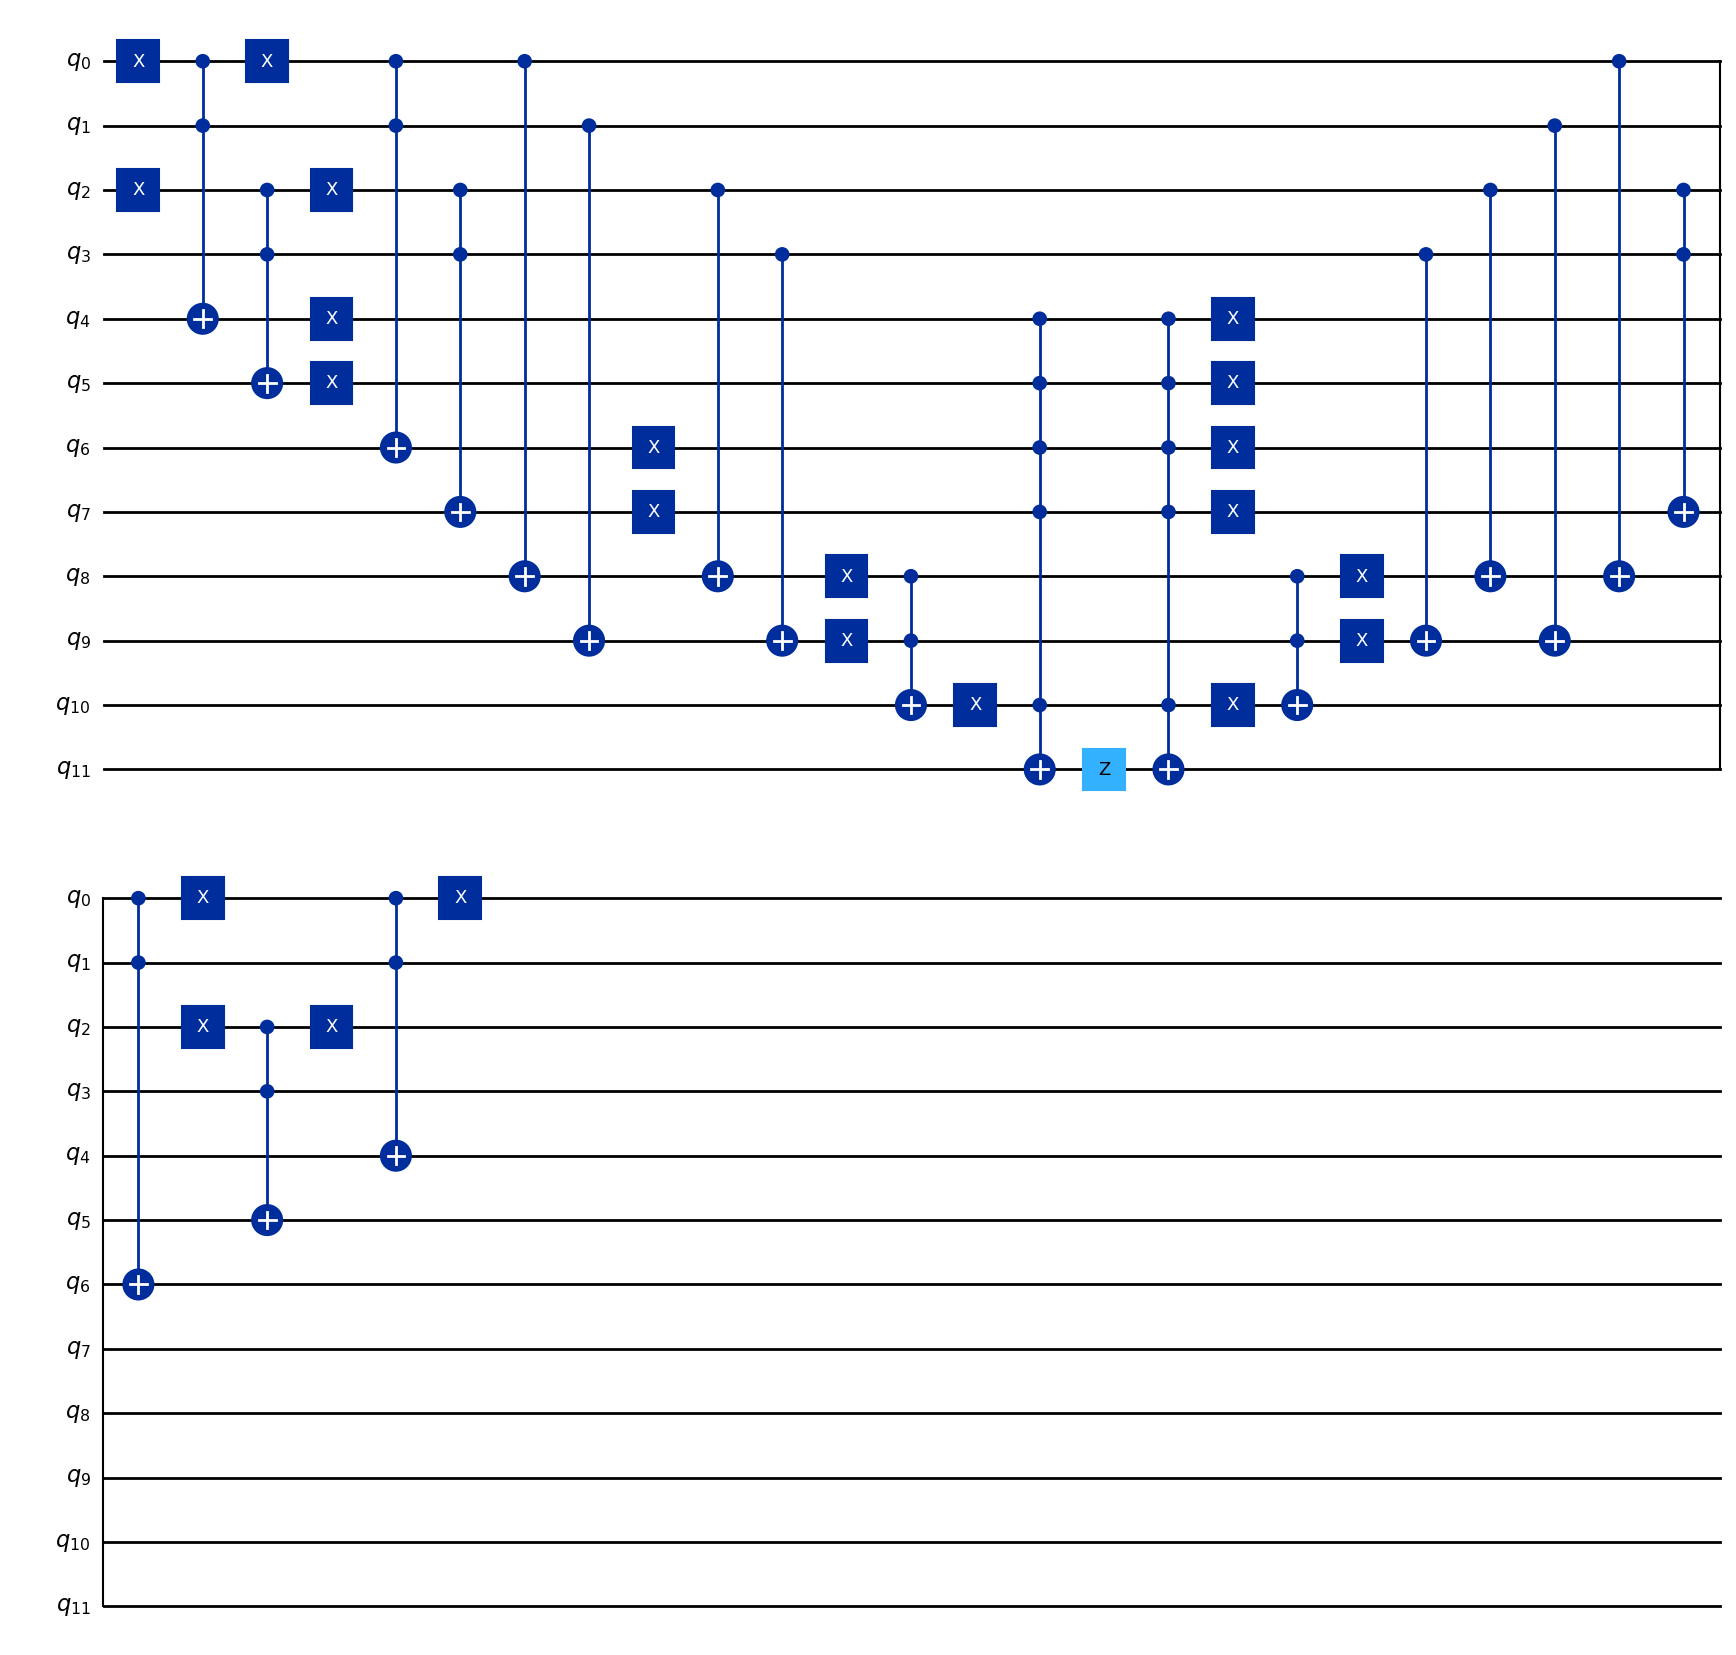

In [22]:
from qc_lecture_tools.grover import oracle_sudoku

oracle_circuit = oracle_sudoku()
oracle_circuit.draw("mpl")

In [23]:
from qc_lecture_tools.grover import oracle_sudoku

num_data_qubits = 4
num_ancilla_qubits = 8
num_qubits = num_data_qubits + num_ancilla_qubits
qc_grover = QuantumCircuit(num_qubits)
qc_grover.compose(initial_state(num_data_qubits, num_ancilla_qubits), inplace=True)

num_repeat = 2

for i in range(num_repeat):
    qc_grover.compose(oracle_sudoku(), inplace=True)
    qc_grover.compose(
        amplitude_amplification(num_data_qubits, num_ancilla_qubits), inplace=True
    )

print_grover_states(qc_grover, 4)

Found basis states with non-zero amplitudes:
0000 00000000: -0.06  Probability:  0.00
0001 00000000: -0.06  Probability:  0.00
0010 00000000:  0.69  Probability:  0.47
0011 00000000: -0.06  Probability:  0.00
0100 00000000: -0.06  Probability:  0.00
0101 00000000: -0.06  Probability:  0.00
0110 00000000: -0.06  Probability:  0.00
0111 00000000: -0.06  Probability:  0.00
1000 00000000:  0.69  Probability:  0.47
1001 00000000: -0.06  Probability:  0.00
1010 00000000: -0.06  Probability:  0.00
1011 00000000: -0.06  Probability:  0.00
1100 00000000: -0.06  Probability:  0.00
1101 00000000: -0.06  Probability:  0.00
1110 00000000: -0.06  Probability:  0.00
1111 00000000: -0.06  Probability:  0.00
